<a href="https://colab.research.google.com/github/alscop/ESAA-26-1/blob/main/ESAA_OB_week13_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> 딥러닝 파이토치 교과서 13장 p.708~732



## 13.3 적대적 생성 신경망(GAN)이란

- 생성자: 최대한 진짜와 비슷한 데이터 생성하려고 함
- 판별자: 진짜와 가짜 구별

서로 적대적으로 학습함.  
판별자 먼저 학습시킨 후 생성자 학습시키는 과정 반복.

1.  실제 이미지를 입력해서 네트워크(신경망)가 해당 이미지를 진짜로 분류하도록 학습시킴
2. 생성자가 생성한 모조 이미지 입력해 해당 이미지를 가짜로 분류하도록 학습시킴
3. 과정 반복
4. 판별자: 실제 이미지 진짜로 분류 & 모조 이미지 가짜로 분류

생성자, 판별자 둘 다 발전함.

### 13.3.1 GAN 동작 원리

생성자 G와 판별자 D가 경쟁하여 학습 진행.  

판별자 D 학습시킬 때: 생성자 G 고정 & 진짜 이미지는 높은 확률, 가짜 이미지는 낮은 확률을 반환하는 방향으로 가중치 업데이트.  

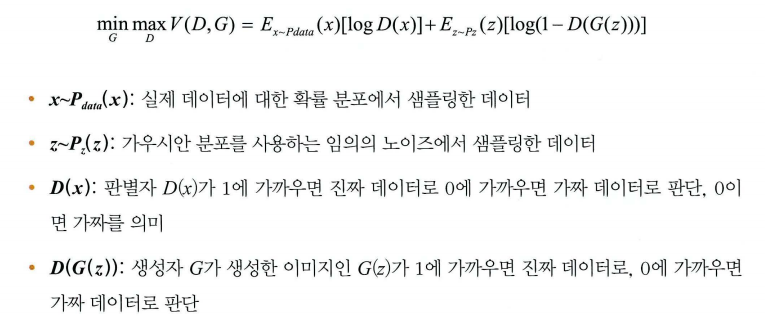


판별자 D: 실제 이미지 x를 입력받을 경우 D(x)를 1로 예측하고， 생성자가 잠재 벡터에서 생성한 모조 이미지 G(z)를 입력받을 경우 D(G(z))를 0으로 예측함.

판별자가 모조이미지 G(x) 입력받을 경우 1로 예측하도록 하는 것이 목표.

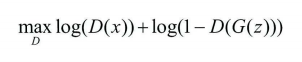



판별자D: 위 식의 최댓값으로 파라미터 업데이트 하는 것이 목표.

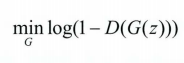




생성자 G: 위 식의 최솟값으로 업데이트

D(G(z)) = 1이 최상의 결과이기 때문 (판별자가 가짜 이미지를 1로 출력한 경우)


GAN 학습을 위해서는 판별자/생성자 파라미터 번갈아 가며 업뎃 해야함.  
서로 업데이트 할 때는 상대의 파라미터 고정해야 함.


### 13.3.2 GAN 구현



In [1]:
# 13-22 라이브러리 호출

import imageio  # 이미지 데이터를 읽고 쓸 수 있는 라이브러리
from tqdm import tqdm  # 반복문 진행 상황 표시

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pylab as plt

from torchvision.utils import make_grid, save_image
import torchvision.datasets as datasets
import torchvision.transforms as transforms

plt.style.use('ggplot')  # 그래프 스타일 설정

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

matplotlib의 stylesheet 바꾸어서 사용함

In [2]:
# 13-23 변수 값 설정

batch_size = 128
epochs = 50

sample_size = 64  # 생성자에 넣을 고정 노이즈 벡터 개수
nz = 128          # 잠재 벡터의 크기, 생성자 입력 크기
k = 1             # 판별자 업데이트 스텝 수

In [3]:
# 13-24 MNIST를 내려받은 후 정규화

transform = transforms.Compose([
    transforms.ToTensor(),                 # 이미지를 텐서로 변환
    transforms.Normalize((0.5,), (0.5,))    # 평균 0.5, 표준편차 0.5로 정규화
])

train_dataset = datasets.MNIST(
    root="../chap13/data",
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0   # Colab에서 RAM 터지면 0으로 두는 게 안전
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 508kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.81MB/s]


In [4]:
# 13-25 생성자 네트워크 생성

class Generator(nn.Module):
    def __init__(self, nz):
        super(Generator, self).__init__()

        self.nz = nz

        self.main = nn.Sequential(
            nn.Linear(self.nz, 256),  # 128차원 노이즈 → 256차원 특징
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),  # 256차원 노이즈 → 512차원 특징
            nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),  # 512차원 노이즈 → 1024차원 특징
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 784),
            nn.Tanh()  # 출력값을 -1~1 범위로 조정
        )

    def forward(self, x):
        return self.main(x).view(-1, 1, 28, 28)  # 배치 크기 × 1 × 28 × 28 형태로 변환

In [5]:
# 13-26 판별자 네트워크 생성

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.n_input = 784  # 28 × 28 이미지 크기

        # 입력 이미지가 이 층들을 차례대로 통과하면서 진짜/가짜 확률을 출력
        self.main = nn.Sequential(
            nn.Linear(self.n_input, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),  # 필요한 핵심 특징을 압축
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),  # 점점 더 최종 판단에 가까운 정보로 압축
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()  # 진짜일 확률을 0~1 사이 값으로 출력
        )

    def forward(self, x):
        x = x.view(-1, 784)  # 이미지를 1차원 벡터로 변환
        return self.main(x)  # 진짜/가짜 분류값 반환

판별자는 이진분류자라는 것을 고려해 신경망 구축함.

In [6]:
# 13-27 생성자와 판별자 네트워크 초기화

generator = Generator(nz).to(device)
discriminator = Discriminator().to(device)

print(generator)
print(discriminator)

Generator(
  (main): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (main): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


생성자는 잠재 벡터 nz라는 변수를 파라미터로 전달해야 함

In [7]:
# 13-28 옵티마이저와 손실 함수 정의

optim_g = optim.Adam(generator.parameters(), lr=0.0002)
optim_d = optim.Adam(discriminator.parameters(), lr=0.0002)

criterion = nn.BCELoss()  # 이진 분류 손실 함수

losses_g = []  # 매 에포크마다 생성자 오차 저장
losses_d = []  # 매 에포크마다 판별자 오차 저장
images = []    # 생성자가 만든 이미지 저장

생성자, 판별자에서 사용할 옵티마이저를 따로 정의해야함

In [8]:
# 13-29 생성된 이미지 저장 함수 정의

def save_generator_image(image, path):
    save_image(image, path)

필수는 아님, 이미지 생성 과정 이해할 수 있도록 시각화해 보여줌

In [9]:
# 13-30 판별자 학습을 위한 함수

def train_discriminator(optimizer, data_real, data_fake):
    b_size = data_real.size(0)  # 배치 크기

    real_label = torch.ones(b_size, 1).to(device)   # 진짜 데이터 라벨 = 1
    fake_label = torch.zeros(b_size, 1).to(device)  # 가짜 데이터 라벨 = 0

    optimizer.zero_grad()

    output_real = discriminator(data_real)
    loss_real = criterion(output_real, real_label)  # 진짜 데이터에 대한 오차

    output_fake = discriminator(data_fake)
    loss_fake = criterion(output_fake, fake_label)  # 가짜 데이터에 대한 오차

    loss_real.backward()
    loss_fake.backward()

    optimizer.step()

    return loss_real + loss_fake  # 판별자의 총 오차 반환

In [10]:
# 13-31 생성자 학습을 위한 함수

def train_generator(optimizer, data_fake):
    b_size = data_fake.size(0)

    real_label = torch.ones(b_size, 1).to(device)  # 생성자는 가짜 이미지를 진짜로 판단받는 것이 목표

    optimizer.zero_grad()

    output = discriminator(data_fake)
    loss = criterion(output, real_label)

    loss.backward()
    optimizer.step()

    return loss

생성자 네트워크에서는 가짜 데이터만 사용하고 있는데， 생성자 입장에서는 가짜 데이터가 실제로 진짜라는 것에 주의할 필요가 있음.

---

In [11]:
# 13-32 모델 학습

import os

os.makedirs("../chap13/img", exist_ok=True)

generator.train()      # 생성자를 학습 모드로 설정
discriminator.train()  # 판별자를 학습 모드로 설정

fixed_noise = torch.randn(sample_size, nz).to(device)  # 이미지 확인용 고정 노이즈

for epoch in range(epochs):
    loss_g = 0.0  # 생성자 오차 누적
    loss_d = 0.0  # 판별자 오차 누적

    for idx, data in tqdm(enumerate(train_loader), total=len(train_loader)):
        image, _ = data
        image = image.to(device)
        b_size = image.size(0)

        # 판별자 학습
        for step in range(k):
            noise = torch.randn(b_size, nz).to(device)
            data_fake = generator(noise).detach()  # 판별자 학습 시 생성자 그래프 차단
            data_real = image

            d_loss = train_discriminator(optim_d, data_real, data_fake)
            loss_d += d_loss.item()  # 숫자만 저장

        # 생성자 학습
        noise = torch.randn(b_size, nz).to(device)
        data_fake = generator(noise)

        g_loss = train_generator(optim_g, data_fake)
        loss_g += g_loss.item()  # 숫자만 저장

    # 에포크 단위 평균 loss 계산
    epoch_loss_g = loss_g / len(train_loader)
    epoch_loss_d = loss_d / len(train_loader)

    losses_g.append(epoch_loss_g)
    losses_d.append(epoch_loss_d)

    # 생성 이미지는 매 에포크마다 한 번만 저장
    with torch.no_grad():
        generated_img = generator(fixed_noise).cpu()
        generated_img = make_grid(generated_img)
        save_generator_image(
            generated_img,
            f"../chap13/img/gen_img{epoch}.png"
        )

    print(f"Epoch {epoch + 1} of {epochs}")
    print(f"Generator loss: {epoch_loss_g:.8f}, Discriminator loss: {epoch_loss_d:.8f}")

100%|██████████| 469/469 [00:18<00:00, 26.01it/s]


Epoch 1 of 50
Generator loss: 3.45972330, Discriminator loss: 0.85184377


100%|██████████| 469/469 [00:15<00:00, 29.65it/s]


Epoch 2 of 50
Generator loss: 10.64257598, Discriminator loss: 0.20240762


100%|██████████| 469/469 [00:19<00:00, 23.66it/s]


...

Epoch 48 of 50
Generator loss: 1.28660198, Discriminator loss: 1.06511848


100%|██████████| 469/469 [00:17<00:00, 26.85it/s]


Epoch 49 of 50
Generator loss: 1.24961526, Discriminator loss: 1.06871619


100%|██████████| 469/469 [00:17<00:00, 27.18it/s]

Epoch 50 of 50
Generator loss: 1.28061108, Discriminator loss: 1.07640550


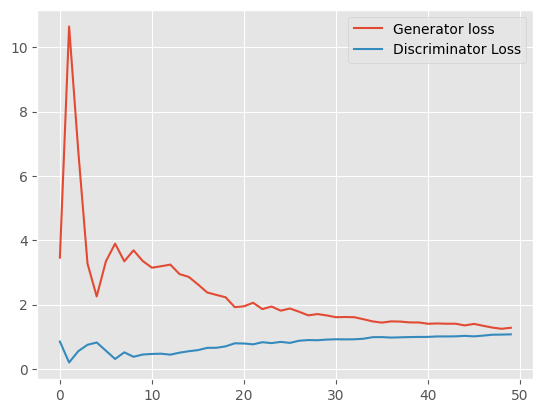

In [12]:
# 13-33 생성자와 판별자의 오차 확인

plt.figure()

plt.plot(losses_g, label='Generator loss')
plt.plot(losses_d, label='Discriminator Loss')

plt.legend()
plt.show()

생성자와 판별자에 대한 오차를 시각적 그래프로 표현한 결과.  

처음 몇 에포크 동안 생성자의 오치는 증가하고 판별자의 오차는 감소
-  학습 초기 단계에 생성자는 좋은 가짜 이미지를 생성하지 못하기
에 판별자가 실제 이미지와 가짜 이미지를 쉽게 구분할 수 있기 때문
- 하지만 학습이 진행됨에 따라 생성지는 진짜와 같은 가짜 이미지를 만들며 판별자는 가짜 이미지 중 일부를 진짜로
분류합


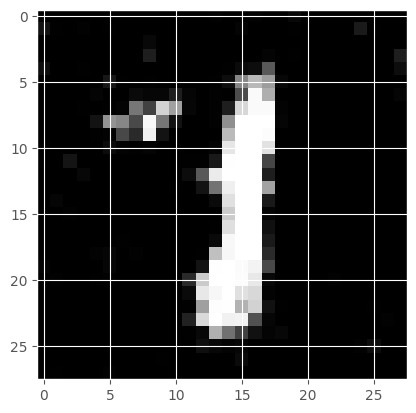

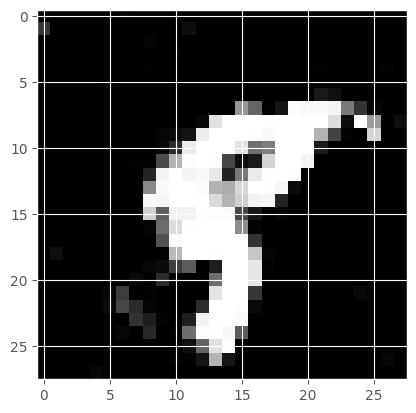

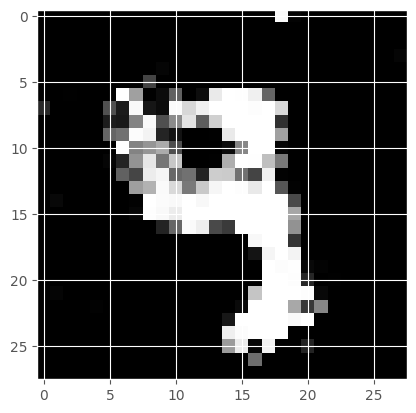

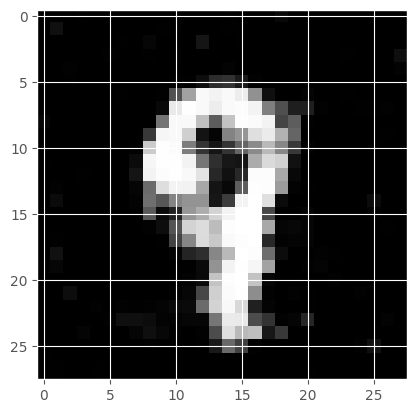

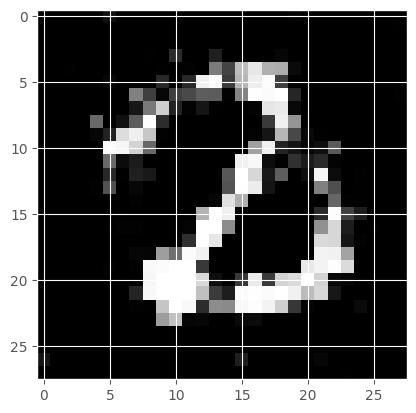

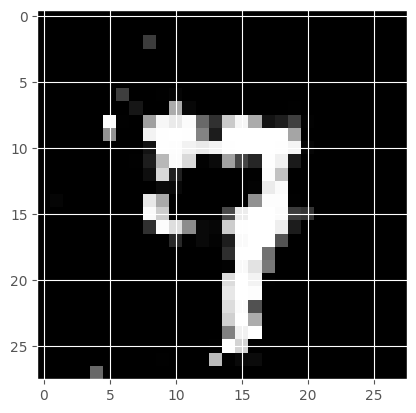

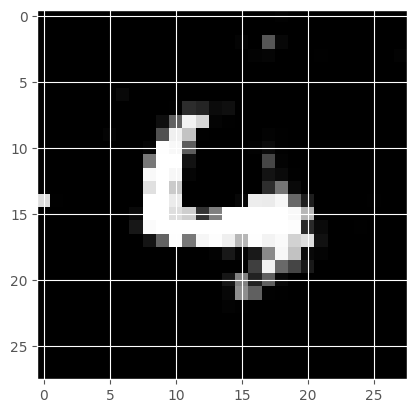

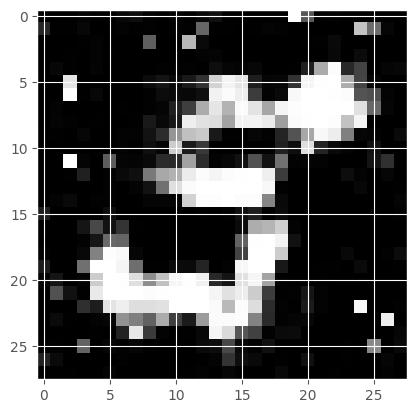

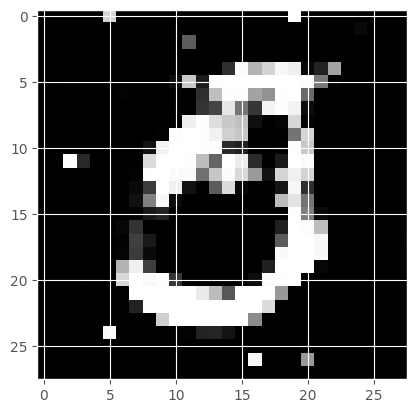

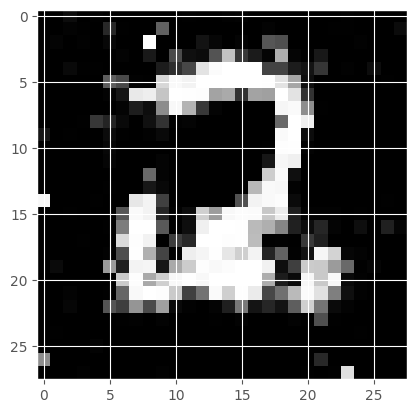

In [13]:
# 13-34 생성된 이미지 출력

import numpy as np  # 배열 변환을 위해 사용

fake_images = generator(torch.randn(b_size, nz).to(device))

for i in range(10):
    fake_images_img = np.reshape(
        fake_images.data.cpu().numpy()[i],
        (28, 28)
    )

    plt.imshow(fake_images_img, cmap='gray')
    plt.savefig('../chap13/img/fake_images_img' + str(i) + '.png')
    plt.show()

## 13.4